# 2. Fits, tables and figures

Reads the tables from compute slopes

* Fig. S1 - dip position vs dip slope on the theory grid (`../figures`)
* Fig. 2  - CV vs sequencing depth with the replicate floors (`../figures`)
* Tables S1-S3 (`../tables`)

In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter
from scipy import stats

SRC_DIR = "other"          
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)
from utils import get_best_t, get_theory_curves

matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42
matplotlib.rc("font", family="DejaVu Sans", weight="medium", size=14)

## Settings

In [2]:
DATASETS_DIR = Path("../data/datasets")
TABLES_DIR   = Path("../tables")
FIGURES_DIR  = Path("../figures")

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

AGG_PARQUET  = DATASETS_DIR / "dip_peak.parquet"
BIO_PARQUET  = DATASETS_DIR / "bio_replicates_dip_peak.parquet"
TECH_PARQUET = DATASETS_DIR / "tech_replicates_dip_peak.parquet"

DATASETS = [
    ("U54-ESC4DN-DSG-DpnII-20190530-R1-T1",     "SRR13601502"),
    ("U54-ESC4DN-DSG-DpnII-20190530-R2-T1",     "SRR13601511"),
    ("U54-HFFc6-DSG-DdeI-DpnII-20190711-R1-T1", "SRR13601574"),
    ("U54-HFFc6-DSG-DdeI-DpnII-20191219-R3-T1", "SRR13601583"),
    ("U54-ESC4DN-FA-DpnII-2017524-R1-T1",       "SRR13601520"),
    ("U54-ESC4DN-FA-DpnII-2017524-R1-T2",       "SRR13601529"),
    ("U54-HFFc6-DSG-DpnII-20180319-R1-T1",      "SRR13601592"),
    ("U54-HFFc6-DSG-DpnII-20190102-R2-T1",      "SRR13601599"),
    ("HMEC",                                    "SRR1658680"),
    ("IMR90",                                   "SRR1658676"),
    ("kbm7",                                    "SRR1658708"),
    ("k562",                                    "SRR1658694"),
]
KEEP_SRRS = [srr for _, srr in DATASETS]

# read pairs in each full library
SRR_READS = {
    "SRR13601502": 366_221_722,
    "SRR13601511": 356_532_010,
    "SRR13601520": 357_286_779,
    "SRR13601529": 352_662_959,
    "SRR13601574": 361_132_819,
    "SRR13601583": 368_488_723,
    "SRR13601592": 366_276_096,
    "SRR13601599": 352_711_374,
    "SRR1658680":  456_577_383,
    "SRR1658676":  240_438_944,
    "SRR1658694":  591_854_553,
    "SRR1658708":  388_468_010,
}
mean_full_reads = np.mean([SRR_READS[srr] for srr in KEEP_SRRS])

# names used in the paper
LABEL = {
    "SRR13601502": "hESC-DSG-DpnII-R1-T1",
    "SRR13601511": "hESC-DSG-DpnII-R2-T1",
    "SRR13601520": "hESC-FA-DpnII-R1-T1",
    "SRR13601529": "hESC-FA-DpnII-R1-T2",
    "SRR13601574": "HFFc6-DdeI-DpnII-R1-T1",
    "SRR13601583": "HFFc6-DdeI-DpnII-R3-T1",
    "SRR13601592": "HFFc6-DSG-DpnII-R1-T1",
    "SRR13601599": "HFFc6-DSG-DpnII-R2-T1",
    "SRR1658680":  "HMEC",
    "SRR1658676":  "IMR90",
    "SRR1658694":  "K562",
    "SRR1658708":  "KBM7",
}

# theory grid
T_values = np.arange(60, 301, 10)
v0_values = [0.0001, 0.2, 0.4, 0.6, 0.8, 1, 1.5, 2, 2.5, 3, 3.5,
             4, 4.5, 5, 5.5, 6, 6.5, 7, 7.5, 8, 8.5, 9, 9.6,
             10, 10.5, 11, 11.5, 12, 12.5, 13, 14, 15]

DEPTH_ORDER = ["full (SRR)", "200M", "100M", "50M", "25M", "10M", "1M"]
TABLE_DEPTHS = ["200M", "100M", "50M", "25M", "10M", "1M"]

## Load the dip/peak tables

In [3]:
def depth_label(depth):
    '''Turn a depth like "10000000" into "10M".'''
    if depth == "full":
        return "full"
    n = int(float(depth))
    if n >= 1_000_000:
        return f"{n // 1_000_000}M"
    if n >= 1_000:
        return f"{n // 1_000}k"
    return str(n)


agg_df = pd.read_parquet(AGG_PARQUET)
bio_df = pd.read_parquet(BIO_PARQUET)
tech_df = pd.read_parquet(TECH_PARQUET)

# loop size in kb, used everywhere below
for table in (agg_df, bio_df, tech_df):
    table["peak_kb"] = table["peak_bp"] / 1000

agg_df["depth_label"] = agg_df["depth"].apply(depth_label)
agg_df.loc[agg_df["depth_label"] == "full", "depth_label"] = "full (SRR)"

print(f"agg_df:  {len(agg_df)} rows, depths {sorted(set(agg_df['depth_label']))}")
print(f"bio_df:  {len(bio_df)} rows, groups {sorted(set(bio_df['bio_group']))}")
print(f"tech_df: {len(tech_df)} rows, {tech_df['sample_name'].nunique()} samples")

agg_df:  995 rows, depths ['100M', '10M', '1M', '200M', '25M', '50M', 'full (SRR)']
bio_df:  76 rows, groups ['ESC4DN-DSG-DpnII', 'HFFc6-DSG-DdeI-DpnII', 'HFFc6-DSG-DpnII', 'HMEC', 'IMR90', 'k562', 'kbm7']
tech_df: 51 rows, 6 samples


## Fit T and v0

In [4]:
theory_xmins, theory_ymins, s_grid, v0_values = get_theory_curves(T_values, v0_values)

print(f"theory grid: {len(T_values)} T values x {len(v0_values)} v0 values")
print(f"T from {T_values.min()} to {T_values.max()} kb")

theory grid: 25 T values x 32 v0 values
T from 60 to 300 kb


In [5]:
def add_fit(table):
    '''Fit T and v0 for every row and add T, v0, density and fit_err columns.'''
    T_list, v0_list, err_list = [], [], []

    for _, row in table.iterrows():
        x_kb, y_min = row["x_min_kb"], row["y_min"]
        if np.isnan(x_kb) or np.isnan(y_min):
            T_best, v0_best, err = np.nan, np.nan, np.nan
        else:
            T_best, v0_best, err = get_best_t(
                (x_kb, y_min),
                theory_xmins=theory_xmins, theory_ymins=theory_ymins,
                T_values=T_values, v0_values=v0_values, x_weight=1e-4,
            )
        T_list.append(T_best)
        v0_list.append(v0_best)
        err_list.append(err)

    out = table.copy()
    out["T"] = T_list
    out["v0"] = v0_list
    out["density"] = 1000 / out["T"]
    out["fit_err"] = err_list
    return out.dropna(subset=["T"])


fit_df = add_fit(agg_df)
bio_fit_df = add_fit(bio_df)
tech_fit_df = add_fit(tech_df)

fit_df.to_parquet(DATASETS_DIR / "fit_df.parquet", index=False)
bio_fit_df.to_parquet(DATASETS_DIR / "bio_fit_df.parquet", index=False)
tech_fit_df.to_parquet(DATASETS_DIR / "tech_fit_df.parquet", index=False)

print(f"fitted: {len(fit_df)} rows, {len(bio_fit_df)} bio, {len(tech_fit_df)} tech")
display(fit_df.head())

fitted: 995 rows, 76 bio, 51 tech


,sample_name,srr_name,entity_type,depth,sample_num,selection,deep_bp,deep_slope,peak_bp,peak_slope,x_min_kb,y_min,num_contacts,peak_kb,depth_label,T,v0,density,fit_err
0,U54-ESC4DN-DSG-DpnII-20190530-R1-T1,SRR13601502,srr_full,full,NaN,None,15000.0,-0.923305,71000.0,-0.738644,15.0,-0.923305,104164300,71.0,full (SRR),90,3.0,11.111111,0.000049
1,U54-ESC4DN-DSG-DpnII-20190530-R1-T1,SRR13601502,sample,10000000,13.0,all,16000.0,-0.924125,73000.0,-0.733987,16.0,-0.924125,3258422,73.0,10M,90,3.0,11.111111,0.000089
2,U54-ESC4DN-DSG-DpnII-20190530-R1-T1,SRR13601502,sample,10000000,11.0,all,16000.0,-0.917533,71000.0,-0.731152,16.0,-0.917533,3259799,71.0,10M,90,3.0,11.111111,0.000042
3,U54-ESC4DN-DSG-DpnII-20190530-R1-T1,SRR13601502,sample,10000000,16.0,all,15000.0,-0.923497,69000.0,-0.737173,15.0,-0.923497,3260712,69.0,10M,90,3.0,11.111111,0.000051
4,U54-ESC4DN-DSG-DpnII-20190530-R1-T1,SRR13601502,sample,10000000,12.0,all,15000.0,-0.927493,63000.0,-0.735780,15.0,-0.927493,3258317,63.0,10M,90,3.0,11.111111,0.000117


## Fig. S1

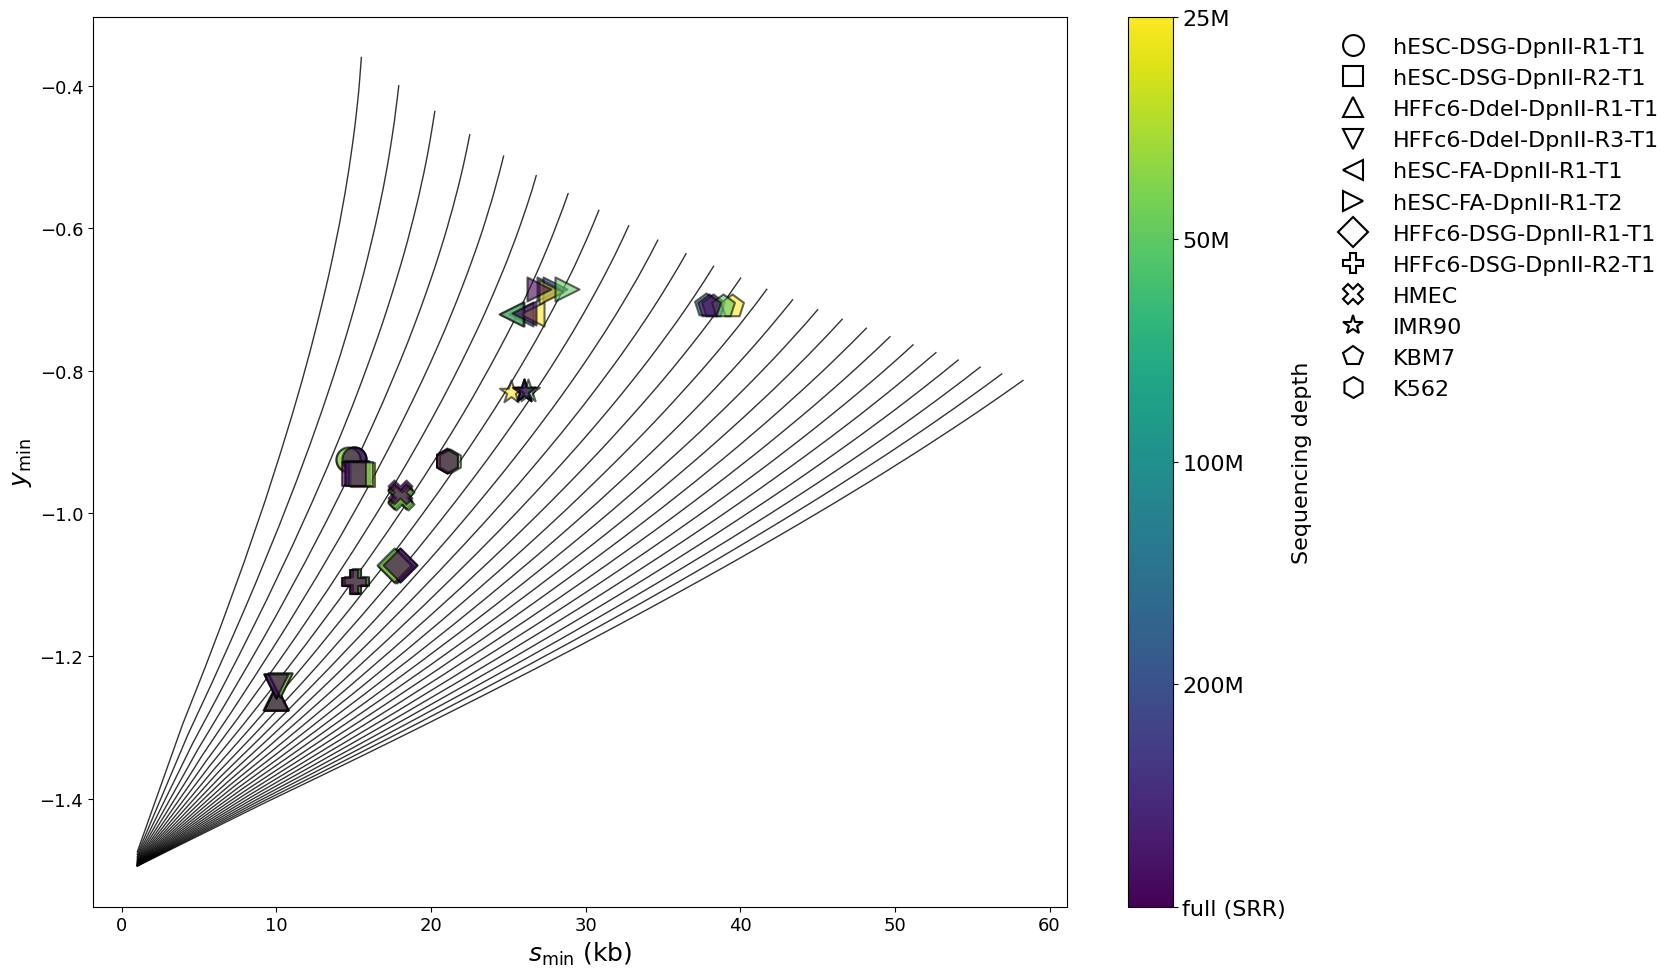

In [6]:
FIGS1_DEPTHS = ["full (SRR)", "200M", "100M", "50M", "25M"]

points = (fit_df[fit_df["depth_label"].isin(FIGS1_DEPTHS)]
          .groupby(["srr_name", "depth_label"])[["x_min_kb", "y_min"]]
          .mean()
          .reset_index())

colors = plt.get_cmap("viridis")(np.linspace(0, 1, len(FIGS1_DEPTHS)))
depth_color = dict(zip(FIGS1_DEPTHS, colors))

markers = ["o", "s", "^", "v", "<", ">", "D", "P", "X", "*", "p", "h"]
srr_marker = {srr: markers[i % len(markers)] for i, srr in enumerate(KEEP_SRRS)}

fig, ax = plt.subplots(figsize=(17, 10))

for T in T_values:
    ax.plot(theory_xmins[T], theory_ymins[T], color="black", lw=1, alpha=0.8)

for _, row in points.iterrows():
    ax.scatter(row["x_min_kb"], row["y_min"],
               s=300, marker=srr_marker.get(row["srr_name"], "o"),
               facecolor=depth_color[row["depth_label"]], edgecolor="k",
               linewidths=1.5, alpha=0.6, zorder=5)

# colorbar for depth
scale = plt.cm.ScalarMappable(cmap=plt.get_cmap("viridis"),
                              norm=plt.Normalize(0, len(FIGS1_DEPTHS) - 1))
scale.set_array([])
cbar = plt.colorbar(scale, ax=ax, ticks=np.arange(len(FIGS1_DEPTHS)))
cbar.ax.set_yticklabels(FIGS1_DEPTHS, fontsize=16)
cbar.set_label("Sequencing depth", fontsize=16)

# legend for datasets
handles = [Line2D([0], [0], marker=srr_marker[srr], linestyle="None",
                  markerfacecolor="none", markeredgecolor="k",
                  markeredgewidth=1.5, markersize=15, label=LABEL[srr])
           for srr in KEEP_SRRS]
ax.legend(handles=handles, frameon=False, bbox_to_anchor=(1.25, 1.0),
          loc="upper left", fontsize=16)

ax.set_xlabel(r"$s_{\min}$ (kb)", fontsize=18)
ax.set_ylabel(r"$y_{\min}$", fontsize=18)
ax.tick_params(labelsize=13)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "figS1_dip_theory_grid.png", dpi=300, bbox_inches="tight")
plt.show()


## Biological and technical floor

The floor is the mean CV inside replicate groups: biological replicates give
the upper floor, technical replicates the lower one.

In [7]:
def cv_per_group(table, group_col, column):
    '''Mean, sd, n and CV of one column inside each replicate group.'''
    stats_table = (table.groupby(group_col)[column]
                        .agg(["mean", "std", "count"])
                        .reset_index())
    stats_table.columns = [group_col, "mean", "sd", "n"]
    stats_table["cv"] = stats_table["sd"] / stats_table["mean"].abs()
    return stats_table


def floor_value(stats_table):
    '''Mean CV over the groups that have at least two replicates.'''
    return stats_table[stats_table["n"] >= 2]["cv"].mean()


bio_density = cv_per_group(bio_fit_df, "bio_group", "density")
bio_size    = cv_per_group(bio_df, "bio_group", "peak_kb")
bio_slope   = cv_per_group(bio_df, "bio_group", "peak_slope")

tech_density = cv_per_group(tech_fit_df, "sample_name", "density")
tech_size    = cv_per_group(tech_df, "sample_name", "peak_kb")
tech_slope   = cv_per_group(tech_df, "sample_name", "peak_slope")

floor_bio_density = floor_value(bio_density)
floor_bio_size    = floor_value(bio_size)
floor_bio_slope   = floor_value(bio_slope)

floor_tech_density = floor_value(tech_density)
floor_tech_size    = floor_value(tech_size)
floor_tech_slope   = floor_value(tech_slope)

print("                biological  technical")
print(f"loop density  {100 * floor_bio_density:9.2f}% {100 * floor_tech_density:9.2f}%")
print(f"loop size     {100 * floor_bio_size:9.2f}% {100 * floor_tech_size:9.2f}%")
print(f"peak slope    {100 * floor_bio_slope:9.2f}% {100 * floor_tech_slope:9.2f}%")

                biological  technical
loop density      13.43%      2.53%
loop size          6.51%      1.02%
peak slope         4.73%      0.09%


In [19]:
def cv_per_srr(table, column, depth):
    '''CV of one column across the subsamples of each library at one depth.'''
    subsamples = table[(table["entity_type"] == "sample") &
                       (table["depth_label"] == depth) &
                       (table["srr_name"].isin(KEEP_SRRS))]
    stats_table = (subsamples.groupby("srr_name")[column]
                             .agg(["mean", "std"])
                             .reset_index())
    stats_table.columns = ["srr_name", "mean", "sd"]
    stats_table["cv"] = 100 * stats_table["sd"] / stats_table["mean"].abs()
    return stats_table


def cv_vs_depth(table, column):
    '''Mean CV over libraries at every depth, with its standard error.

    Returns the reads, the CV in percent and the error, starting from the
    full-depth point where the CV is zero by construction.
    '''
    depths = [d for d in TABLE_DEPTHS if d in set(table["depth_label"])]

    reads = [mean_full_reads]
    cv_mean = [0.0]
    cv_error = [0.0]

    for depth in depths:
        values = cv_per_srr(table, column, depth)["cv"].dropna()
        reads.append(int(float(depth.replace("M", "")) * 1e6))
        cv_mean.append(values.mean())
        # cv_error.append(values.std(ddof=1) / np.sqrt(len(values)) if len(values) > 1 else 0.0)
        cv_error.append(values.std(ddof=0) if len(values) > 1 else 0.0)


    return np.array(reads), np.array(cv_mean), np.array(cv_error)


reads_density, cv_density, err_density = cv_vs_depth(fit_df, "density")
reads_size, cv_size, err_size = cv_vs_depth(agg_df, "peak_kb")
reads_slope, cv_slope, err_slope = cv_vs_depth(agg_df, "peak_slope")

depth_cv_df = pd.DataFrame({"reads": reads_density,
                            "density_cv": cv_density,
                            "density_cv_err": err_density,
                            "loop_size_cv": cv_size,
                            "loop_size_cv_err": err_size,
                            "peak_slope_cv": cv_slope,
                            "peak_slope_cv_err": err_slope})
depth_cv_df.to_parquet(DATASETS_DIR / "cv_vs_depth.parquet", index=False)
display(depth_cv_df)

,reads,density_cv,density_cv_err,loop_size_cv,loop_size_cv_err,peak_slope_cv,peak_slope_cv_err
0,3.798876e+08,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2.000000e+08,2.997946,3.883644,1.411634,1.267358,0.102891,0.072045
2,1.000000e+08,3.726518,3.164688,1.916114,1.155326,0.178358,0.076877
3,5.000000e+07,6.375859,3.790139,3.241533,1.583405,0.308553,0.115858
4,2.500000e+07,7.931925,3.297635,5.935034,3.308664,0.461410,0.201614
5,1.000000e+07,10.741511,5.182719,8.691992,3.667750,0.641512,0.145143
6,1.000000e+06,19.574823,7.941865,18.837186,5.706932,1.781519,0.545395


## Table S1 - loop density vs depth

In [15]:
def stats_at_depth(table, column, srr_name, depth):
    '''Mean, sd and number of subsamples of one column for one library.'''
    values = table[(table["entity_type"] == "sample") &
                   (table["srr_name"] == srr_name) &
                   (table["depth_label"] == depth)][column]
    if len(values) == 0:
        return np.nan, np.nan, 0
    return values.mean(), values.std(ddof=1), len(values)


rows = []
for sample_name, srr_name in DATASETS:
    full = fit_df[(fit_df["srr_name"] == srr_name) &
                  (fit_df["entity_type"] == "srr_full")]
    if len(full) == 0:
        continue
    full = full.iloc[0]

    row = {"Dataset": LABEL[srr_name],
           "SRR": srr_name,
           "Density full (loops/Mb)": round(full["density"], 2),
           "v0 eff (kb)": round(full["v0"], 2),
           "T (kb)": round(full["T"], 1)}

    for depth in TABLE_DEPTHS:
        mean, sd, n = stats_at_depth(fit_df, "density", srr_name, depth)
        row[f"Density {depth}"] = round(mean, 2)
        row[f"SD {depth}"] = round(sd, 2)
        row[f"n {depth}"] = n

    rows.append(row)

table_s1 = pd.DataFrame(rows)
table_s1.to_csv(TABLES_DIR / "tableS1_loop_density_by_depth.csv", index=False)
print(f"saved {TABLES_DIR / 'tableS1_loop_density_by_depth.csv'}")
display(table_s1)

saved ../tables/tableS1_loop_density_by_depth.csv


,Dataset,SRR,Density full (loops/Mb),v0 eff (kb),T (kb),Density 200M,SD 200M,n 200M,Density 100M,SD 100M,...,n 50M,Density 25M,SD 25M,n 25M,Density 10M,SD 10M,n 10M,Density 1M,SD 1M,n 1M
0,hESC-DSG-DpnII-R1-T1,SRR13601502,11.11,3.0,90,11.11,0.00,4,11.11,0.00,...,10,11.60,0.68,20,11.47,0.73,20,11.41,2.39,25
1,hESC-DSG-DpnII-R2-T1,SRR13601511,10.00,3.0,100,10.00,0.00,4,10.00,0.00,...,10,10.18,0.60,20,10.16,0.83,20,10.49,1.58,25
2,HFFc6-DdeI-DpnII-R1-T1,SRR13601574,7.69,0.6,130,7.69,0.00,4,7.69,0.00,...,10,7.82,0.26,20,7.79,0.23,20,7.82,0.69,25
3,HFFc6-DdeI-DpnII-R3-T1,SRR13601583,9.09,0.6,110,9.09,0.00,4,9.09,0.00,...,10,8.66,0.80,20,8.31,0.97,20,7.86,1.01,25
4,hESC-FA-DpnII-R1-T1,SRR13601520,8.33,8.5,120,8.36,0.57,4,8.08,0.35,...,10,8.10,0.94,20,8.77,1.09,20,9.02,2.42,25
5,hESC-FA-DpnII-R1-T2,SRR13601529,8.33,9.6,120,7.69,0.00,4,7.97,0.63,...,10,7.97,1.01,20,8.28,1.61,20,8.61,3.05,25
6,HFFc6-DSG-DpnII-R1-T1,SRR13601592,7.69,2.0,130,7.18,0.59,4,7.49,0.46,...,10,7.67,0.50,20,7.54,0.76,20,6.78,1.11,25
7,HFFc6-DSG-DpnII-R2-T1,SRR13601599,9.09,1.5,110,8.60,0.97,4,8.70,0.87,...,10,8.57,1.07,20,8.50,1.19,20,8.86,1.65,25
8,HMEC,SRR1658680,9.09,3.0,110,8.71,0.44,4,8.64,0.41,...,10,8.52,0.34,20,8.56,0.36,20,8.52,0.95,25
9,IMR90,SRR1658676,7.14,6.5,140,7.14,0.00,4,7.36,0.30,...,10,7.61,0.89,20,7.36,1.49,20,7.32,2.26,25


## Table S2 - loop size vs depth

In [16]:
rows = []
for sample_name, srr_name in DATASETS:
    full = agg_df[(agg_df["srr_name"] == srr_name) &
                  (agg_df["entity_type"] == "srr_full")]
    if len(full) == 0:
        continue
    full = full.iloc[0]

    row = {"Sample": LABEL[srr_name],
           "SRR": srr_name,
           "Loop size full (kb)": round(full["peak_kb"], 1)}

    for depth in TABLE_DEPTHS:
        size_mean, size_sd, n = stats_at_depth(agg_df, "peak_kb", srr_name, depth)
        slope_mean, slope_sd, _ = stats_at_depth(agg_df, "peak_slope", srr_name, depth)
        row[f"Loop size {depth} (kb)"] = round(size_mean, 1)
        row[f"SD {depth} (kb)"] = round(size_sd, 1)
        row[f"Peak slope {depth}"] = round(slope_mean, 3)
        row[f"Peak slope SD {depth}"] = round(slope_sd, 3)
        row[f"n {depth}"] = n

    rows.append(row)

table_s2 = pd.DataFrame(rows)
table_s2.to_csv(TABLES_DIR / "tableS2_loop_size_by_depth.csv", index=False)
print(f"saved {TABLES_DIR / 'tableS2_loop_size_by_depth.csv'}")
display(table_s2)

saved ../tables/tableS2_loop_size_by_depth.csv


,Sample,SRR,Loop size full (kb),Loop size 200M (kb),SD 200M (kb),Peak slope 200M,Peak slope SD 200M,n 200M,Loop size 100M (kb),SD 100M (kb),...,Loop size 10M (kb),SD 10M (kb),Peak slope 10M,Peak slope SD 10M,n 10M,Loop size 1M (kb),SD 1M (kb),Peak slope 1M,Peak slope SD 1M,n 1M
0,hESC-DSG-DpnII-R1-T1,SRR13601502,71.0,70.5,0.6,-0.739,0.000,4,70.4,1.5,...,71.2,5.0,-0.738,0.004,20,74.6,10.2,-0.730,0.010,25
1,hESC-DSG-DpnII-R2-T1,SRR13601511,75.0,74.0,0.0,-0.751,0.001,4,74.2,0.4,...,75.0,5.8,-0.750,0.005,20,71.9,14.0,-0.744,0.014,25
2,HFFc6-DdeI-DpnII-R1-T1,SRR13601574,104.0,103.5,0.6,-0.850,0.000,4,103.4,1.1,...,104.5,4.2,-0.848,0.005,20,112.6,16.4,-0.845,0.015,25
3,HFFc6-DdeI-DpnII-R3-T1,SRR13601583,102.0,101.2,1.3,-0.887,0.001,4,101.8,0.8,...,101.2,4.7,-0.888,0.006,20,100.1,12.3,-0.881,0.013,25
4,hESC-FA-DpnII-R1-T1,SRR13601520,74.0,73.8,1.3,-0.652,0.002,4,75.2,1.5,...,73.9,11.6,-0.654,0.005,20,78.2,22.4,-0.637,0.018,25
5,hESC-FA-DpnII-R1-T2,SRR13601529,82.0,82.0,1.4,-0.632,0.001,4,80.8,3.8,...,84.0,9.6,-0.630,0.006,20,86.0,24.5,-0.614,0.018,25
6,HFFc6-DSG-DpnII-R1-T1,SRR13601592,106.0,104.8,1.0,-0.817,0.001,4,105.0,1.6,...,105.4,4.4,-0.817,0.005,20,102.9,11.4,-0.812,0.012,25
7,HFFc6-DSG-DpnII-R2-T1,SRR13601599,100.0,99.5,1.0,-0.899,0.000,4,99.0,1.0,...,99.6,5.7,-0.899,0.006,20,102.2,17.3,-0.891,0.014,25
8,HMEC,SRR1658680,100.0,99.8,1.3,-0.775,0.002,4,98.4,3.6,...,101.1,10.9,-0.773,0.005,20,101.8,22.1,-0.763,0.012,25
9,IMR90,SRR1658676,91.0,89.8,0.5,-0.780,0.000,4,90.0,1.9,...,88.0,7.6,-0.779,0.004,20,91.7,19.8,-0.769,0.012,25


## Table S3 - CV within replicates

In [17]:
def cv_table(density, size, slope, group_col, replicate_type):
    '''One block of table S3: CV of the three metrics per group.'''
    rows = []
    for _, row in density.iterrows():
        group = row[group_col]
        size_row = size[size[group_col] == group].iloc[0]
        slope_row = slope[slope[group_col] == group].iloc[0]
        rows.append({"Group / sample": group,
                     "Replicate type": replicate_type,
                     "n": int(row["n"]),
                     "Density CV (%)": round(100 * row["cv"], 2),
                     "Peak size CV (%)": round(100 * size_row["cv"], 2),
                     "Peak slope CV (%)": round(100 * slope_row["cv"], 2)})
    return pd.DataFrame(rows)


def short_name(name):
    '''Drop the date from a library name.'''
    return re.sub(r"-\d{6,8}-", "-", name)


bio_block = cv_table(bio_density, bio_size, bio_slope, "bio_group", "biological")
tech_block = cv_table(tech_density, tech_size, tech_slope, "sample_name", "technical")
tech_block["Group / sample"] = tech_block["Group / sample"].apply(short_name)

mean_rows = pd.DataFrame([
    {"Group / sample": "mean (biological)", "Replicate type": "biological",
     "n": np.nan,
     "Density CV (%)": round(100 * floor_bio_density, 2),
     "Peak size CV (%)": round(100 * floor_bio_size, 2),
     "Peak slope CV (%)": round(100 * floor_bio_slope, 2)},
    {"Group / sample": "mean (technical)", "Replicate type": "technical",
     "n": np.nan,
     "Density CV (%)": round(100 * floor_tech_density, 2),
     "Peak size CV (%)": round(100 * floor_tech_size, 2),
     "Peak slope CV (%)": round(100 * floor_tech_slope, 2)},
])

table_s3 = pd.concat([bio_block, tech_block, mean_rows], ignore_index=True)
table_s3.to_csv(TABLES_DIR / "tableS3_replicate_cv.csv", index=False)
print(f"saved {TABLES_DIR / 'tableS3_replicate_cv.csv'}")
display(table_s3)

saved ../tables/tableS3_replicate_cv.csv


,Group / sample,Replicate type,n,Density CV (%),Peak size CV (%),Peak slope CV (%)
0,ESC4DN-DSG-DpnII,biological,18.0,8.71,2.38,0.86
1,HFFc6-DSG-DdeI-DpnII,biological,18.0,8.57,1.10,2.25
2,HFFc6-DSG-DpnII,biological,15.0,12.13,3.40,4.90
3,HMEC,biological,6.0,11.41,2.98,2.87
4,IMR90,biological,8.0,22.99,21.40,9.12
5,k562,biological,6.0,18.12,6.37,10.02
6,kbm7,biological,5.0,12.05,7.97,3.10
7,U54-ESC4DN-DSG-DpnII-R1-T1,technical,9.0,6.00,1.38,0.12
8,U54-ESC4DN-DSG-DpnII-R2-T1,technical,9.0,0.00,0.94,0.13
9,U54-HFFc6-DSG-DdeI-DpnII-R1-T1,technical,9.0,0.00,0.58,0.08


## Fig. 2

loop density: mean = 5.0M ± 5.7M read pairs, from 5.0M to 16.3M
loop size: mean = 20.6M ± 15.9M read pairs, from 6.5M to 38.4M


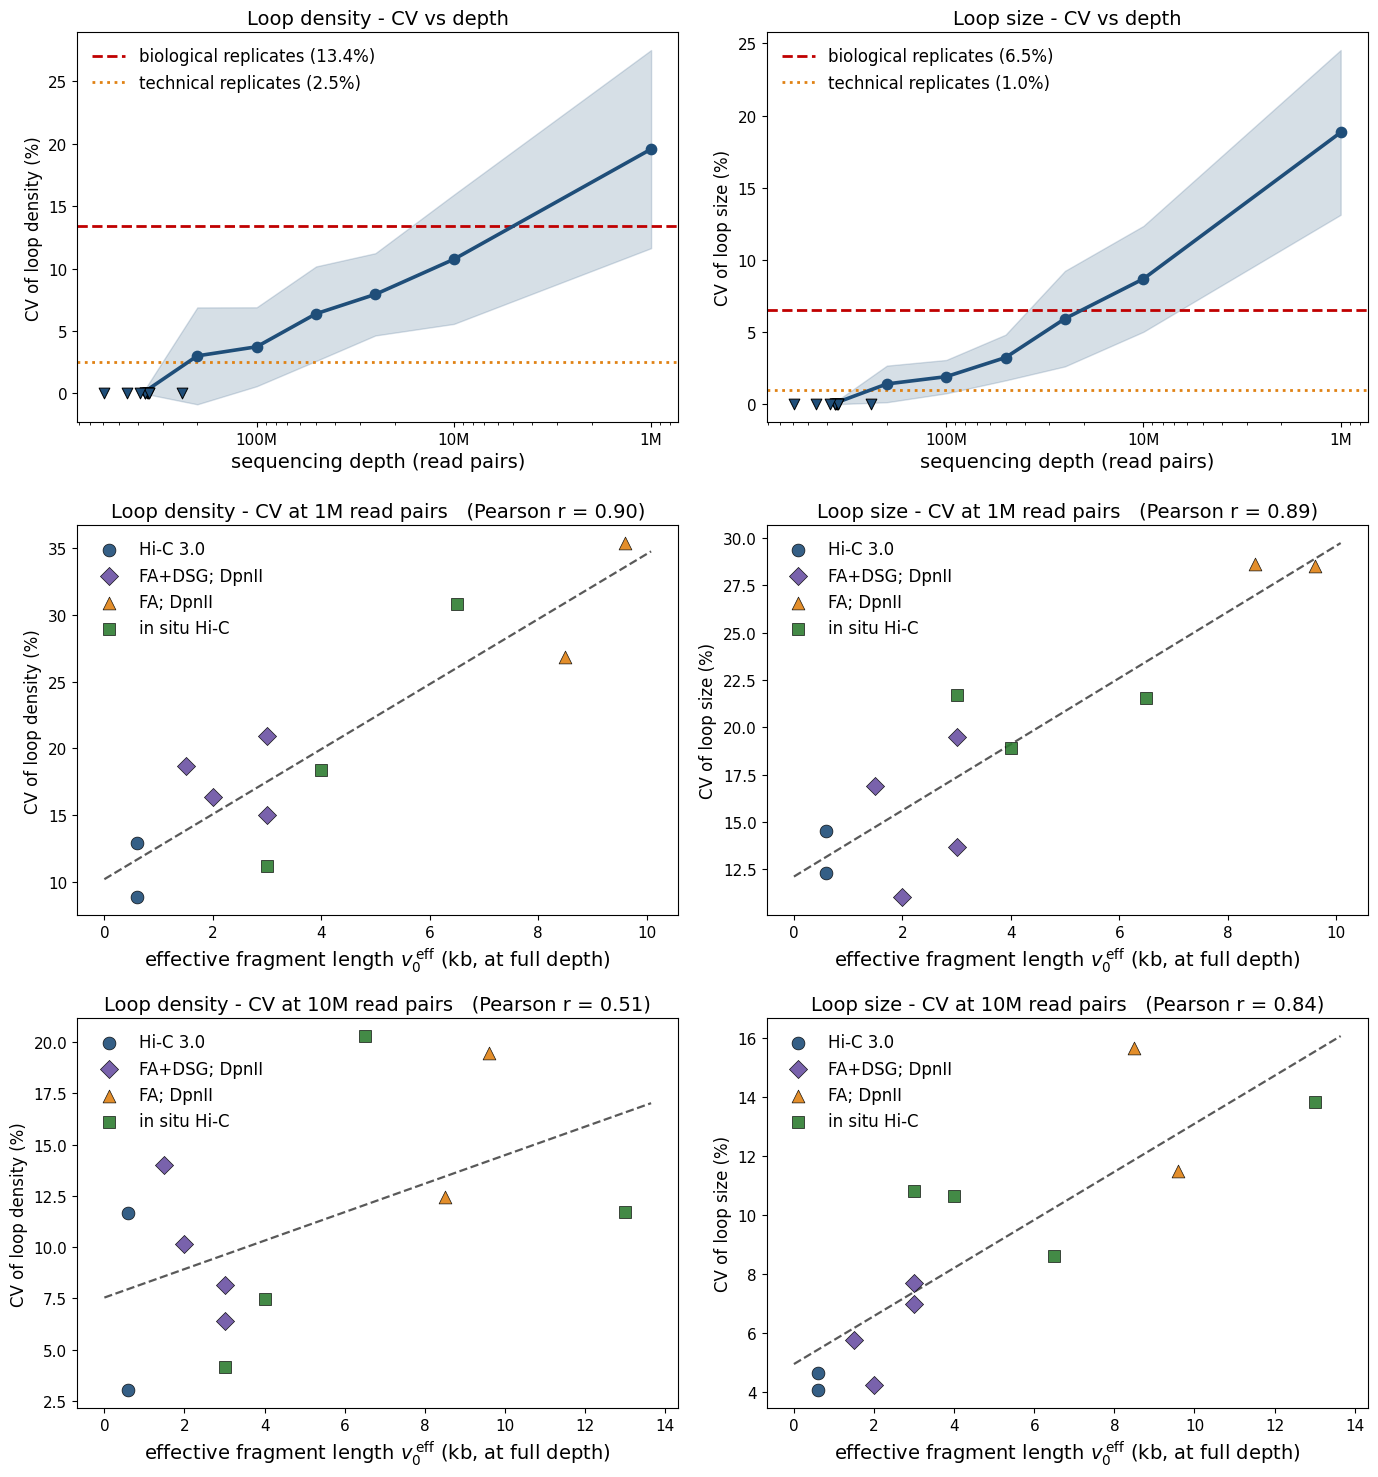

In [22]:
COLOR_CURVE = "#1f4e79"
COLOR_BIO = "#c00000"
COLOR_TECH = "#e08214"

PROTOCOL_STYLE = {
    "Hi-C 3.0":      {"color": "#1f4e79", "marker": "o"},
    "FA+DSG; DpnII": {"color": "#6a51a3", "marker": "D"},
    "FA; DpnII":     {"color": "#e08214", "marker": "^"},
    "in situ Hi-C":  {"color": "#2e7d32", "marker": "s"},
}

read_format = FuncFormatter(lambda x, _: f"{int(x / 1e6)}M" if x >= 1e6 else f"{int(x / 1e3)}k")

def interp_crossing(reads, values, floor):
    '''Depth at which a curve crosses the floor, interpolated in log10(depth).'''
    order = np.argsort(reads)
    x = np.asarray(reads, float)[order]
    y = np.asarray(values, float)[order]

    for i in range(len(x) - 1):
        below = y[i] - floor
        above = y[i + 1] - floor
        if below * above <= 0 and (below != 0 or above != 0):
            t = below / (below - above)
            return 10 ** (np.log10(x[i]) + t * (np.log10(x[i + 1]) - np.log10(x[i])))
    return None


def floor_crossing(reads, cv, sd, floor):
    '''Crossing of the biological floor, with the ±1 s.d. band as its uncertainty.'''
    floor_percent = 100 * floor
    center = interp_crossing(reads, cv, floor_percent)
    if center is None:
        return None

    low = interp_crossing(reads, cv - sd, floor_percent)
    high = interp_crossing(reads, cv + sd, floor_percent)
    if low is None:
        low = center
    if high is None:
        high = center
    low, high = min(low, high), max(low, high)

    error = (abs(center - low) + abs(center - high)) / 2
    return center, low, high, error


def print_crossing(name, reads, cv, sd, floor):
    '''Print the depth at which a CV curve reaches the biological floor.'''
    result = floor_crossing(reads, cv, sd, floor)
    if result is None:
        print(f"{name}: does not reach the biological floor "
              f"({100 * floor:.1f}%) within the tested depths")
        return

    center, low, high, error = result
    print(f"{name}: mean = {center / 1e6:.1f}M ± {error / 1e6:.1f}M read pairs, "
          f"from {low / 1e6:.1f}M to {high / 1e6:.1f}M")
    
def protocol(sample_name):
    '''Which Hi-C protocol a library was made with.'''
    if "DdeI" in sample_name:
        return "Hi-C 3.0"
    if "DSG" in sample_name:
        return "FA+DSG; DpnII"
    if "FA" in sample_name:
        return "FA; DpnII"
    return "in situ Hi-C"


def plot_cv_vs_depth(ax, reads, cv, error, floor_bio, floor_tech, ylabel, title):
    '''Top row of figure 2: CV against depth with the two floors.'''
    ax.plot(reads, cv, "-", color=COLOR_CURVE, lw=2.6, zorder=3)
    ax.scatter(reads[1:], cv[1:], color=COLOR_CURVE, s=55, zorder=4)
    ax.fill_between(reads, cv - error, cv + error, color=COLOR_CURVE, alpha=0.18)

    for srr in KEEP_SRRS:
        ax.scatter(SRR_READS[srr], 0, marker="v", s=60, color=COLOR_CURVE,
                   edgecolors="k", linewidths=0.7, zorder=5)

    ax.axhline(100 * floor_bio, color=COLOR_BIO, lw=2, ls="--",
               label=f"biological replicates ({100 * floor_bio:.1f}%)")
    ax.axhline(100 * floor_tech, color=COLOR_TECH, lw=2, ls=":",
               label=f"technical replicates ({100 * floor_tech:.1f}%)")

    ax.set_xscale("log")
    ax.invert_xaxis()
    ax.xaxis.set_major_formatter(read_format)
    ax.set_xlabel("sequencing depth (read pairs)", fontsize=14)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.tick_params(labelsize=11)
    ax.legend(fontsize=12, frameon=False, loc="upper left")


full_v0 = (fit_df[fit_df["entity_type"] == "srr_full"][["srr_name", "sample_name", "v0"]]
           .drop_duplicates("srr_name"))


def plot_cv_vs_v0(ax, table, column, depth, ylabel, title):
    '''Lower rows of figure 2: CV at one depth against the effective fragment length.'''
    points = full_v0.merge(cv_per_srr(table, column, depth)[["srr_name", "cv"]],
                           on="srr_name")
    points = points.dropna(subset=["cv"])
    points["protocol"] = points["sample_name"].apply(protocol)

    title_text = title
    if len(points) >= 3 and points["v0"].nunique() > 1:
        slope, intercept, r_value, p_value, _ = stats.linregress(points["v0"], points["cv"])
        line_x = np.linspace(0, points["v0"].max() * 1.05, 50)
        ax.plot(line_x, intercept + slope * line_x, "--", color="0.35", lw=1.6)
        title_text = f"{title}   (Pearson r = {r_value:.2f})"

    for name, style in PROTOCOL_STYLE.items():
        group = points[points["protocol"] == name]
        if len(group) > 0:
            ax.scatter(group["v0"], group["cv"], s=85, alpha=0.9, zorder=5,
                       color=style["color"], marker=style["marker"],
                       edgecolors="k", linewidths=0.5, label=name)

    ax.set_xlabel(r"effective fragment length $v_{0}^{\:\mathrm{eff}}$ (kb, at full depth)")
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title_text, fontsize=14)
    ax.tick_params(labelsize=11)
    ax.legend(fontsize=12, frameon=False, loc="upper left")

print_crossing("loop density", reads_density, cv_density, err_density, floor_bio_density)
print_crossing("loop size", reads_size, cv_size, err_size, floor_bio_size)


fig, axes = plt.subplots(3, 2, figsize=(14, 15))

plot_cv_vs_depth(axes[0, 0], reads_density, cv_density, err_density,
                 floor_bio_density, floor_tech_density,
                 "CV of loop density (%)", "Loop density - CV vs depth")
plot_cv_vs_depth(axes[0, 1], reads_size, cv_size, err_size,
                 floor_bio_size, floor_tech_size,
                 "CV of loop size (%)", "Loop size - CV vs depth")

plot_cv_vs_v0(axes[1, 0], fit_df, "density", "1M",
              "CV of loop density (%)", "Loop density - CV at 1M read pairs")
plot_cv_vs_v0(axes[1, 1], agg_df, "peak_kb", "1M",
              "CV of loop size (%)", "Loop size - CV at 1M read pairs")

plot_cv_vs_v0(axes[2, 0], fit_df, "density", "10M",
              "CV of loop density (%)", "Loop density - CV at 10M read pairs")
plot_cv_vs_v0(axes[2, 1], agg_df, "peak_kb", "10M",
              "CV of loop size (%)", "Loop size - CV at 10M read pairs")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig2_density_loopsize_stability.png", dpi=300, bbox_inches="tight")
plt.show()
